# VEC-IoT MASAC — Complete Colab




In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
PROJECT='/content/drive/MyDrive/vec_iot_project'
os.chdir(PROJECT)
print(os.getcwd())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/vec_iot_project


In [ ]:
# Dependency check (avoid forced NumPy upgrades in Colab)
import numpy as np, scipy, sklearn, matplotlib, pandas as pd, torch
print('numpy       ', np.__version__)
print('scipy       ', scipy.__version__)
print('scikit-learn', sklearn.__version__)
print('pandas      ', pd.__version__)
print('torch       ', torch.__version__)


numpy        2.1.3
scipy        1.16.3
scikit-learn 1.6.1
pandas       2.2.3
torch        2.11.0+cpu


In [ ]:
!python -m py_compile src/*.py train_masac.py evaluate_masac.py
print('Compilation successful.')


Compilation successful.


## Network diagnostic


In [ ]:
!python diagnose_network.py --vehicles datasets/vehicles.xml --tasks datasets/tasks.xml --max-tasks 500


tasks checked: 500
best-direct rate Mbps: mean= 0.737007210634504 min= 0.2153039564028733 max= 6.438495968596395
best-direct packet loss: mean= 0.5638994741682285
best-direct latency s: mean= 32.915969598447155


## Quick training — only if you want to retrain/check training


In [ ]:
!python train_masac.py --vehicles datasets/vehicles.xml --tasks datasets/tasks.xml --episodes 6 --max-tasks 2000


## Full training — only when training a fresh model


In [ ]:
!python train_masac.py --vehicles datasets/vehicles.xml --tasks datasets/tasks.xml --episodes 2 --max-tasks 15000


## Evaluation — rerun this after replacing `evaluate_masac.py`; retraining is not required for the matched-scenario patch


In [ ]:
!python evaluate_masac.py --vehicles datasets/vehicles.xml --tasks datasets/tasks.xml --model outputs/masac.pt --max-tasks 10000


Loaded MASAC model on cpu
Number of UAVs (K): 5
Number of edge servers: 10

================ MASAC EVALUATION ================
Tasks                         = 10000
Average total latency         = 20.125029 s
Average total energy          = 9.82434664 J
Network packet loss           = 0.593511
Average NETWORK data rate     = 0.683 Mbps
Network/offloaded tasks       = 6095
Task success rate             = 58.76%
No-feasible-route tasks       = 192

Required MATCHED communication scenario comparison:
  Matched task pairs          = 5719
  UAV-relay samples           = 5719
  No-UAV samples              = 5719
  UAV-relay avg latency       = 37.262259 s
  UAV-relay avg bitrate       = 0.626 Mbps
  No-UAV avg latency          = 31.593702 s
  No-UAV avg bitrate          = 0.753 Mbps

MASAC route distribution:
  DIRECT_E0            = 389
  DIRECT_E6            = 449
  DIRECT_E7            = 242
  DIRECT_E9            = 417
  E1->E0               = 476
  E2->E7               = 25
  E3->E2    

# Load results


In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
OUT=os.path.join(PROJECT,'outputs')
evaluation=pd.read_csv(os.path.join(OUT,'evaluation.csv'))
scenarios=pd.read_csv(os.path.join(OUT,'evaluation_scenarios.csv'))
edge_load=pd.read_csv(os.path.join(OUT,'evaluation_edge_load.csv'))
uav_positions=pd.read_csv(os.path.join(OUT,'uav_positions.csv'))
uav_presence=pd.read_csv(os.path.join(OUT,'uav_presence.csv'))
print('routes:')
print(evaluation['route'].value_counts())
display(evaluation.head())


## Average total latency: UAV relay vs no UAV relay — matched tasks


UAV-relay samples:    5719
No-UAV-relay samples: 5719
Matched task pairs:   5719


,Average Total Latency (s)
UAV Relay,37.262259
No UAV Relay,31.593702


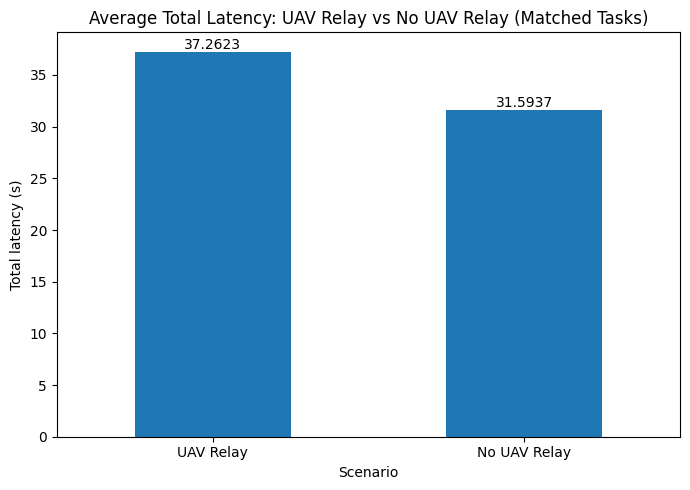

In [ ]:
# Average Total Latency: matched UAV Relay vs matched No UAV Relay
uav = scenarios[scenarios['scenario'] == 'UAV-relay'].copy()
no_uav = scenarios[scenarios['scenario'] == 'No-UAV-relay'].copy()

print(f'UAV-relay samples:    {len(uav)}')
print(f'No-UAV-relay samples: {len(no_uav)}')

if len(uav) != len(no_uav):
    raise ValueError('Scenario CSV is not matched. Re-run the revised evaluate_masac.py first.')
if len(uav) == 0:
    raise ValueError('No matched UAV/no-UAV tasks were feasible in this evaluation.')

# Optional integrity check: every pair_id must have exactly two rows.
if 'pair_id' in scenarios.columns:
    pair_sizes = scenarios.groupby('pair_id')['scenario'].nunique()
    if not (pair_sizes == 2).all():
        raise ValueError('Some scenario pairs are incomplete.')
    print(f'Matched task pairs:   {len(pair_sizes)}')

vals = pd.Series({
    'UAV Relay': uav['latency_s'].mean(),
    'No UAV Relay': no_uav['latency_s'].mean(),
})
display(vals.to_frame(name='Average Total Latency (s)'))

ax = vals.plot(kind='bar', figsize=(7, 5))
ax.set_title('Average Total Latency: UAV Relay vs No UAV Relay (Matched Tasks)')
ax.set_xlabel('Scenario')
ax.set_ylabel('Total latency (s)')
for patch, value in zip(ax.patches, vals.values):
    ax.text(patch.get_x()+patch.get_width()/2, patch.get_height(), f'{value:.4f}', ha='center', va='bottom')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Average total energy


Average total energy: 9.824347 J


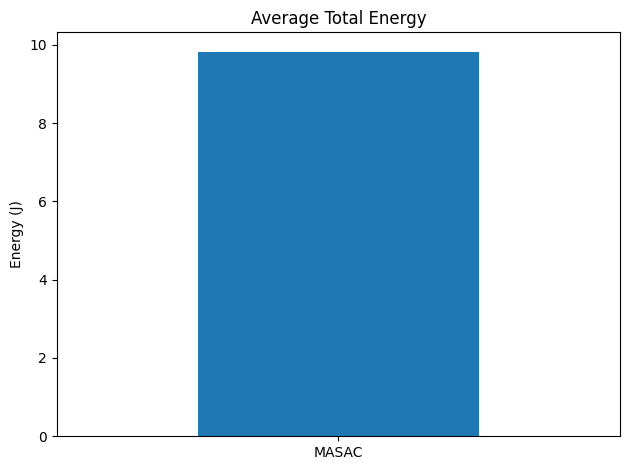

In [ ]:
v=evaluation['energy_j'].mean()
print(f'Average total energy: {v:.6f} J')
ax=pd.Series({'MASAC':v}).plot(kind='bar'); ax.set_title('Average Total Energy'); ax.set_ylabel('Energy (J)'); plt.xticks(rotation=0); plt.tight_layout(); plt.show()


## Packet loss


Average network packet loss: 0.593511


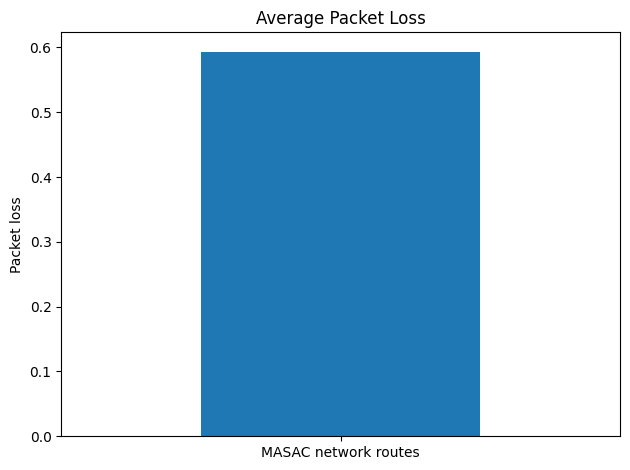

In [ ]:
network=evaluation[np.isfinite(pd.to_numeric(evaluation['avg_rate_bps'],errors='coerce'))].copy()
if len(network):
    v=network['packet_loss'].mean(); print(f'Average network packet loss: {v:.6f}')
    ax=pd.Series({'MASAC network routes':v}).plot(kind='bar'); ax.set_title('Average Packet Loss'); ax.set_ylabel('Packet loss'); plt.xticks(rotation=0); plt.tight_layout(); plt.show()
else:
    print('No network/offloaded MASAC tasks were selected.')


## Average data rate — network routes only


Average network data rate: 0.683 Mbps


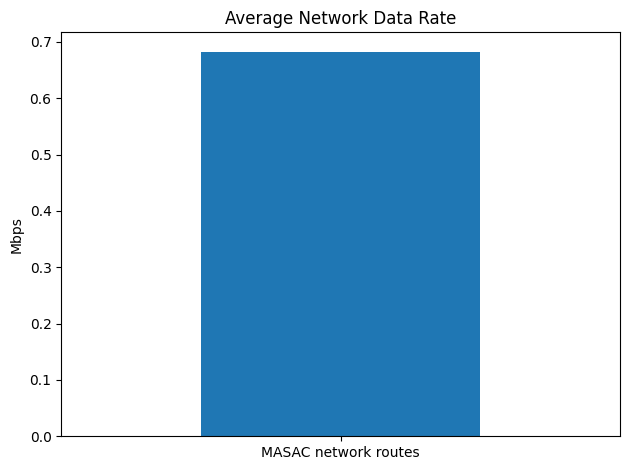

In [ ]:
network=evaluation[np.isfinite(pd.to_numeric(evaluation['avg_rate_bps'],errors='coerce'))].copy()
if len(network):
    v=network['avg_rate_bps'].mean()/1e6; print(f'Average network data rate: {v:.3f} Mbps')
    ax=pd.Series({'MASAC network routes':v}).plot(kind='bar'); ax.set_title('Average Network Data Rate'); ax.set_ylabel('Mbps'); plt.xticks(rotation=0); plt.tight_layout(); plt.show()
else:
    print('No network/offloaded MASAC tasks were selected.')


## Load distribution among edge servers


edge
0    0.118520
1    0.027321
2    0.074531
3    0.069575
4    0.020152
5    0.000000
6    0.135994
7    0.037563
8    0.025925
9    0.115669
Name: load, dtype: float64


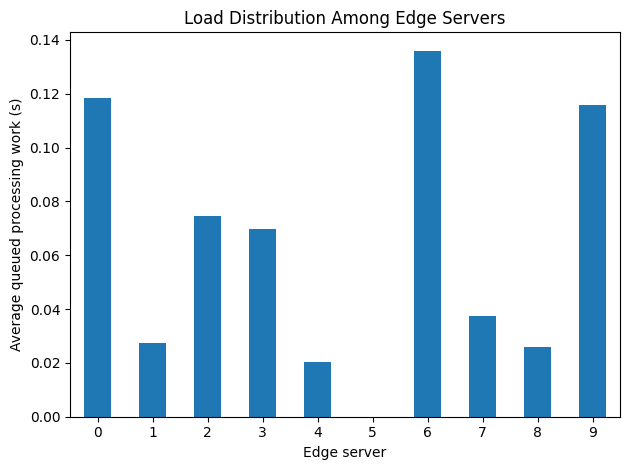

In [ ]:
load_by_edge=edge_load.groupby('edge')['load'].mean()
print(load_by_edge)
ax=load_by_edge.plot(kind='bar'); ax.set_title('Load Distribution Among Edge Servers'); ax.set_xlabel('Edge server'); ax.set_ylabel('Average queued processing work (s)'); plt.xticks(rotation=0); plt.tight_layout(); plt.show()


## Task success rate


Task success rate: 58.76%


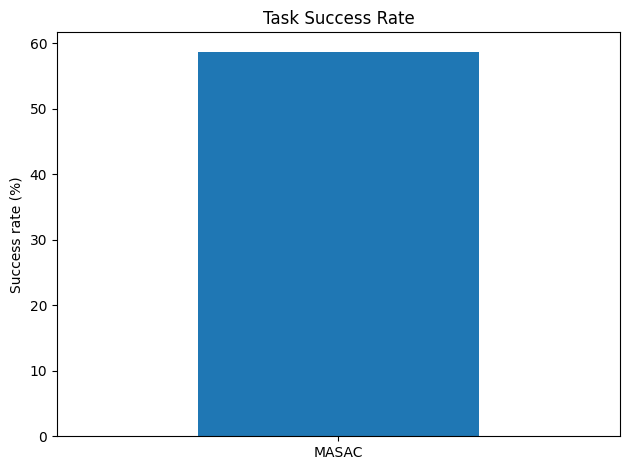

In [ ]:
rate=(evaluation['deadline_miss_s']<=1e-12).mean()*100
print(f'Task success rate: {rate:.2f}%')
ax=pd.Series({'MASAC':rate}).plot(kind='bar'); ax.set_title('Task Success Rate'); ax.set_ylabel('Success rate (%)'); plt.xticks(rotation=0); plt.tight_layout(); plt.show()


## Average UAV presence


In [ ]:
v=uav_presence['uav_count'].mean() if len(uav_presence) else 0.0
print(f'Average UAV presence: {v:.3f} UAVs/timestep')


Average UAV presence: 5.000 UAVs/timestep


## UAV movement on the map


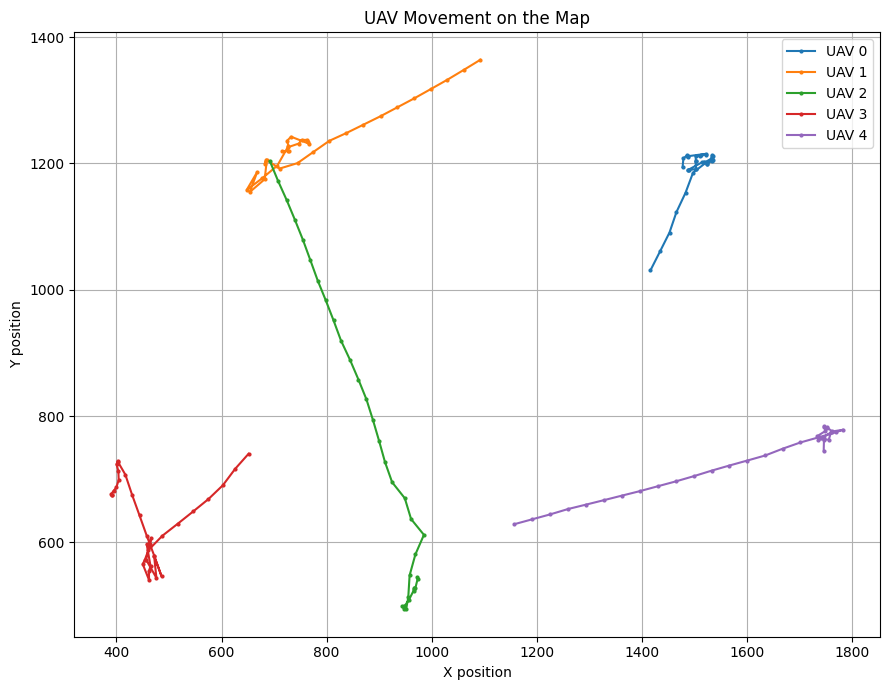

In [ ]:
plt.figure(figsize=(9,7))
for uid,g in uav_positions.groupby('uav_id'):
    plt.plot(g['x'],g['y'],marker='o',markersize=2,label=f'UAV {uid}')
plt.title('UAV Movement on the Map'); plt.xlabel('X position'); plt.ylabel('Y position'); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


## MASAC route distribution


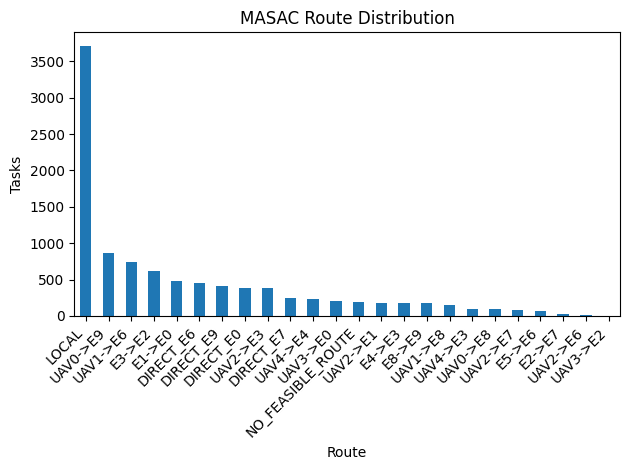

In [ ]:
x=evaluation['route'].value_counts()
ax=x.plot(kind='bar'); ax.set_title('MASAC Route Distribution'); ax.set_xlabel('Route'); ax.set_ylabel('Tasks'); plt.xticks(rotation=45,ha='right'); plt.tight_layout(); plt.show()
